# Stratified (quiet) resampling

When a beam is downsampled to fewer macroparticles, random resampling adds shot noise.

`ParticleGroup.stratified_resample(n, key=...)` instead sorts the alive particles along `key`, splits them into `n` equal-count strata, and draws one particle per stratum. This "quiet" loading suppresses (at long wavelengths) the sampling noise that random downsampling introduces

Here we demonstrate this on an idealized Gaussian bunch. In the limit of infinite particles, the bunching factor has closed form $B(\lambda) = e^{-2\pi^2 \sigma_z^2 / \lambda^2}$.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from beamphysics import ParticleGroup

## An idealized Gaussian bunch

Build a Gaussian bunch with spread in `z` (and a fixed time), 1 nC total charge, with equal particle weights.

In [19]:
rng = np.random.default_rng(0)

n_full = 1_000_000
sigma_z = 100e-6

data = dict(
    x=rng.normal(0, 100e-6, n_full),
    px=rng.normal(0, 1e3, n_full),
    y=rng.normal(0, 100e-6, n_full),
    py=rng.normal(0, 1e3, n_full),
    z=rng.normal(0, sigma_z, n_full),
    pz=np.full(n_full, 1e9) + rng.normal(0, 1e6, n_full),
    t=np.zeros(n_full),
    status=np.ones(n_full, dtype=int),
    weight=np.full(n_full, 1e-9 / n_full),  # 1 nC, equal weights
    species="electron",
)

P = ParticleGroup(data=data)
P

<ParticleGroup with 1000000 particles at 0x31b327d90>

## Downsample two ways

Reduce the bunch to the same small number of macroparticles using the random method and the stratified method. Both preserve the total charge and return equally weighted particles.

In [25]:
n_down = 10_000

# Random down-sampling (default). Seed numpy's global RNG for a reproducible figure.
np.random.seed(0)
P_random = P.resample(n_down)

# Stratified (quiet) down-sampling along z.
# Equivalent to: P.resample(n_down, method="stratified", key="z")
P_strat = P.stratified_resample(n_down, key="z")

for label, Q in [("full", P), ("random", P_random), ("stratified", P_strat)]:
    print(f"{label:>11}: n={Q.n_particle:>7}, charge={Q.charge:.4e} C")

       full: n=1000000, charge=1.0000e-09 C
     random: n=  10000, charge=1.0000e-09 C
 stratified: n=  10000, charge=1.0000e-09 C


## Compare the bunching spectra

Sweep the bunching factor over wavelength for each beam, and overlay the analytic Gaussian form factor. The dashed line marks the $1/\sqrt{n}$ random-sampling noise floor.

In [26]:
wavelengths = np.geomspace(2e-6, 1e-3, 250)

def spectrum(pg):
    return np.array([np.abs(pg.bunching(w)) for w in wavelengths])

b_full = spectrum(P)
b_random = spectrum(P_random)
b_strat = spectrum(P_strat)

# Analytic Gaussian form factor
b_theory = np.exp(-2 * np.pi**2 * sigma_z**2 / wavelengths**2)

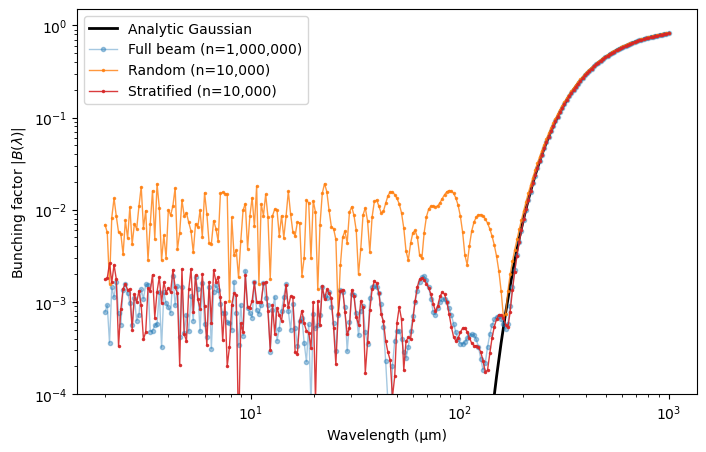

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
wl_um = wavelengths * 1e6

ax.plot(wl_um, b_theory,  "k-", lw=2, label="Analytic Gaussian")
ax.plot(wl_um, b_full, "C0.-", lw=1, alpha=0.4, label=f"Full beam (n={n_full:,})")
ax.plot(wl_um, b_random, "C1.-", ms=3, lw=1, alpha=0.8, label=f"Random (n={n_down:,})")
ax.plot(wl_um, b_strat, "C3.-", ms=3, lw=1, alpha=0.9, label=f"Stratified (n={n_down:,})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.5)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Bunching factor $|B(\\lambda)|$")
ax.legend()
plt.show()